In [366]:
import pandas as pd
import sqlalchemy
import pymysql
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

host = "35.199.115.174"
user = "looqbox-challenge"
password = "looq-challenge"
database = "looqbox-challenge"

engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:3306/{database}"
)

df = pd.read_sql(
    "SHOW TABLES",
    engine
)

df

,Tables_in_looqbox-challenge
0,IMDB_movies
1,data_product
2,data_product_sales
3,data_store_cad
4,data_store_sales


### SQL TEST
#### After accessing our database, create queries using the schema looqbox_challenge to answer the following questions:


#### 1. What are the 10 most expensive products in the company?

In [367]:
query = """
SELECT
      PRODUCT_NAME,
      PRODUCT_VAL
FROM data_product
ORDER BY PRODUCT_VAL desc
LIMIT 10
"""

df = pd.read_sql(query, engine)
df

,PRODUCT_NAME,PRODUCT_VAL
0,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99
1,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90
2,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90
4,Escova Dental Eletrica ORAL B D34 Professional...,399.90
5,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90
6,Champagne Frances Brut Imperial MOET Rose Garr...,359.90
7,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00
8,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,Champagne Frances Brut Imperial MOET & CHANDON...,315.90


#### 2. What sections do the 'BEBIDAS' and 'PADARIA' departments have?

In [368]:
query = """
SELECT DISTINCT
      DEP_NAME,
      SECTION_NAME
FROM data_product
WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA')
ORDER BY DEP_NAME
"""

df = pd.read_sql(query, engine)
df

,DEP_NAME,SECTION_NAME
0,BEBIDAS,BEBIDAS
1,BEBIDAS,CERVEJAS
2,BEBIDAS,REFRESCOS
3,BEBIDAS,VINHOS
4,PADARIA,DOCES-E-SOBREMESAS
5,PADARIA,GESTANTE
6,PADARIA,PADARIA
7,PADARIA,QUEIJOS-E-FRIOS


#### 3. What was the total sale of products (in $) of each Business Area in the first quarter of 2019?

In [369]:

query = """
SELECT
  BUSINESS_NAME,
  SUM(SALES_VALUE) AS SALES_VALUE
FROM data_store_cad dsc
LEFT JOIN data_store_sales dss ON dsc.STORE_CODE = dss.STORE_CODE
WHERE DATE BETWEEN '2019-01-01' AND '2019-04-30'
GROUP BY BUSINESS_NAME
ORDER BY BUSINESS_NAME
"""

df = pd.read_sql(query, engine)
df['SALES_VALUE'] = df['SALES_VALUE'].map('{:,.2f}'.format)
df

,BUSINESS_NAME,SALES_VALUE
0,Atacado,"106,961,594.56"
1,Farma,"108,311,473.65"
2,Posto,"42,425,463.16"
3,Proximidade,"106,678,792.46"
4,Varejo,"107,845,926.10"


### CASES

#### 1) The Dev Team was tired of developing the same old queries just varying the filters accordingly to their boss demands. As a new member of the crew, your mission now is to create a dynamic function in Python, on the most flexible of ways, to produce queries and retrieve a dataframe based on three parameters:

- `product_code`: integer
- `store_code`: integer
- `date`: list of ISO-like strings

#### Date e.g.

['2019-01-01', '2019-01-31']
It should look like this my_data = retrieve_data(product_code, store_code, date)

Make your team proud!

Extra instructions:

Retrieve all columns from table data_product_sales;
Imagine people from other teams will also utilize this function!

In [370]:
from sqlalchemy import text
import pandas as pd

def retrieve_data(
    product_code=None,
    store_code=None,
    date=None
):

    conditions = []
    params = {}

    if product_code is not None:
        conditions.append(
            "product_code = :product_code"
        )
        params["product_code"] = product_code

    if store_code is not None:
        conditions.append(
            "store_code = :store_code"
        )
        params["store_code"] = store_code

    if date is not None:
        conditions.append(
            "date BETWEEN :start_date AND :end_date"
        )

        params["start_date"] = date[0]
        params["end_date"] = date[1]

    where_clause = ""

    if conditions:
        where_clause = "WHERE " + " AND ".join(conditions)

    query = text(f"""
        SELECT *
        FROM data_product_sales
        {where_clause}
    """)

    return pd.read_sql(
        query,
        engine,
        params=params
    )

#### Documentação da função `retrieve_data`

A função `retrieve_data` permite consultar dados de vendas de maneira rápida e flexível. Ao informar um produto, uma loja e/ou um período, a função retorna apenas os registros que atendem aos critérios selecionados.

#### Como utilizar

Execute o comando da célula abaixo, substituindo os valores pelos filtros desejados.

```python
df = retrieve_data(
    product_code=18,
    store_code=18,
    date=['2019-01-01', '2019-01-05']
)
```

#### Parâmetros

| Parâmetro | Descrição |
|------------|------------|
| `product_code` | Código do produto a ser filtrado (número inteiro) |
| `store_code` | Código da loja a ser filtrada (número inteiro) |
| `date` | Período da consulta no formato `['YYYY-MM-DD', 'YYYY-MM-DD']` |

#### Observações

- Todos os parâmetros são opcionais.
- Caso nenhum filtro seja informado, a função retornará todos os registros da tabela.
- As datas devem ser informadas no formato `YYYY-MM-DD`.

#### Retorno da consulta

A função retorna uma tabela contendo as seguintes colunas:

| Coluna | Descrição |
|---------|------------|
| `STORE_CODE` | Código da loja |
| `PRODUCT_CODE` | Código do produto |
| `DATE` | Data da venda |
| `SALES_VALUE` | Valor total das vendas |
| `SALES_QTY` | Quantidade vendida |

In [371]:
my_data = retrieve_data(
  product_code=18,
  store_code=18,
  date=['2019-01-01', '2019-01-05']
)

print(my_data)

  STORE_CODE  PRODUCT_CODE        DATE  SALES_VALUE  SALES_QTY
0         18            18  2019-01-01        708.5       65.0
1         18            18  2019-01-02       1297.1      119.0
2         18            18  2019-01-03       1144.5      105.0
3         18            18  2019-01-04       1090.0      100.0
4         18            18  2019-01-05        893.8       82.0


2) A brand new client sent you two ready-to-go queries. Those are listed below:

Query 1:
```sql
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
```
Query 2:
```sql
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
```

In addition, he gave you this set of instructions:

Use the queries as they are (do not modify them or create a new one);

Please filter the period between this given range:

```python
['2019-10-01', '2019-12-31']
```
We are in need of this visualization (click here to see it)! Please, create it with Python

In [372]:
query_store = """
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
"""

df_store = pd.read_sql(query_store, engine)
df_store.head()



,STORE_CODE,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,Sao Paulo,2006-10-01,,Varejo,1
1,2,Chicago,2007-10-01,,Varejo,1
2,3,Roma,2008-10-01,,Varejo,1
3,4,Tokio,2009-10-01,,Varejo,1
4,5,Paris,2019-01-01,,Proximidade,2


In [373]:
query_sales = """
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

df_sales = pd.read_sql(query_sales, engine)
df_sales.head()

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,2019-01-01,196623.22,12838
1,10,2019-01-01,126795.44,4933
2,11,2019-01-01,223937.00,7724
3,12,2019-01-01,200251.80,7043
4,13,2019-01-01,196623.22,12838


In [374]:
df_sales['DATE'] = pd.to_datetime(df_sales['DATE'])

df_sales = df_sales[(df_sales['DATE'] >= '2019-10-01') & (df_sales['DATE'] <= '2019-12-31')]

df = pd.merge(df_store, df_sales, on='STORE_CODE', how='inner')

tm = (df.groupby(['STORE_NAME', 'BUSINESS_NAME'], as_index=False).agg({'SALES_VALUE': 'sum', 'SALES_QTY': 'sum'}))

tm['TM'] = (tm['SALES_VALUE'] / tm['SALES_QTY']).round(2)

tm = tm.rename(columns={'STORE_NAME': 'Loja', 'BUSINESS_NAME': 'Categoria'})

tm_final = tm[['Loja', 'Categoria', 'TM']].sort_values('Loja')
tm_final


,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


#### 3) Building your own visualization
Create at least one chart using the table IMDB_movies. The code must be in Python, and you are free to use any libraries, data in the table and graphic format. Explain why you chose the visualization (or visualizations) you are submitting.

In [375]:
query_movies = """
SELECT
      *
FROM IMDB_movies
"""

df = pd.read_sql(query_movies, engine)
df.head()

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0


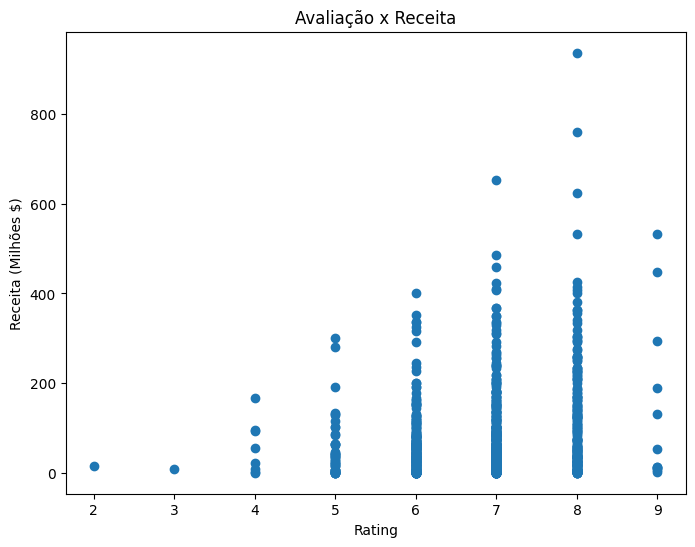

In [376]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Rating'],
    df['RevenueMillions']
)

plt.title('Avaliação x Receita')
plt.xlabel('Rating')
plt.ylabel('Receita (Milhões $)')

plt.show()

##### O gráfico de dispersão foi utilizado para analisar a relação entre avaliação dos filmes e a receita. Observa-se uma tendência positiva indicando, de maneira geral,  que os filmes com notas mais altas tendem a apresentar receitas maiores. Porém, há casos de filmes com notas mais altas e receitas modestas, indicando outros fatores além da avaliação que podem influenciar no desempenho financeiro.

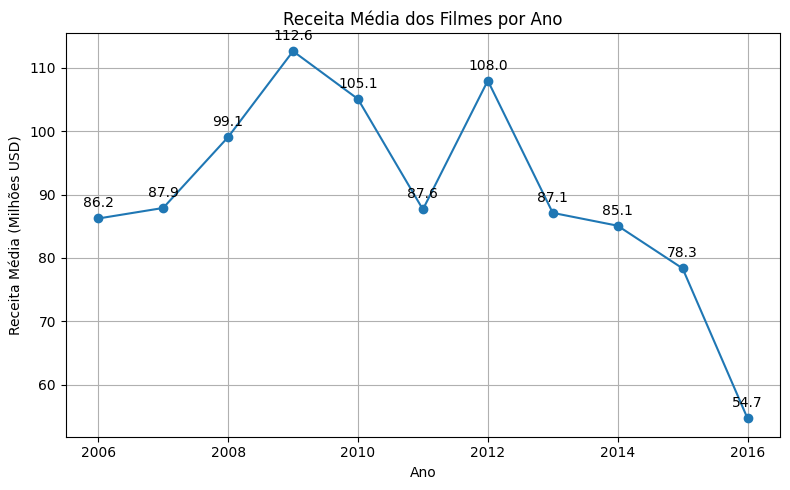

In [377]:
revenue_by_year = (
    df
    .groupby('Year')['RevenueMillions']
    .mean()
)

plt.figure(figsize=(8,5))

plt.plot(
    revenue_by_year.index,
    revenue_by_year.values,
    marker='o'
)

for ano, receita in zip(revenue_by_year.index, revenue_by_year.values):
    plt.annotate(
        f'{receita:.1f}',
        (ano, receita),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

plt.title('Receita Média dos Filmes por Ano')
plt.xlabel('Ano')
plt.ylabel('Receita Média (Milhões USD)')
plt.grid(True)

plt.tight_layout()
plt.show()

##### O gráfico de linha foi utilizado para analisar a evolução da receita média dos filmes ao longo dos anos. Observa-se um crescimento gradual entre 2006 e 2009, atingindo o pico de 112,6 milhões de dólares. Após isso, ocorreram oscilações e uma tendência de redução, com destaque para o ano de 2016.

In [378]:
df_genre = df.copy()
df_genre['Genre'] = df_genre['Genre'].str.split(',')
df_genre = df_genre.explode('Genre')
df_genre

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,Action,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
0,1,Guardians of the Galaxy,Adventure,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
0,1,Guardians of the Galaxy,Sci-Fi,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,Adventure,Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
1,2,Prometheus,Mystery,Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
...,...,...,...,...,...,...,...,...,...,...,...
998,999,Search Party,Adventure,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,NaN,22.0
998,999,Search Party,Comedy,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,6.0,4881,NaN,22.0
999,1000,Nine Lives,Comedy,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.0,12435,20.0,11.0
999,1000,Nine Lives,Family,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.0,12435,20.0,11.0


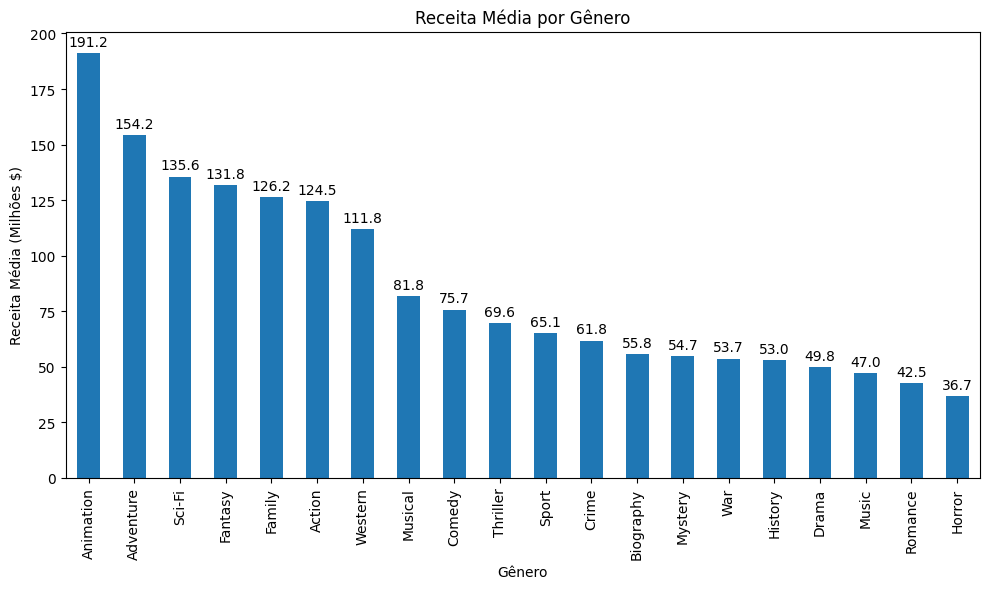

In [379]:
genre_revenue = (
    df_genre
    .groupby('Genre')['RevenueMillions']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

ax = genre_revenue.plot(kind='bar')

# Adiciona os valores acima das barras
for barra in ax.patches:
    altura = barra.get_height()

    ax.annotate(
        f'{altura:.1f}',
        (barra.get_x() + barra.get_width() / 2, altura),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.title('Receita Média por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Receita Média (Milhões $)')

plt.tight_layout()
plt.show()

#### O gráfico de barras foi utilizado para comparar a receita média dos filmes entre os diferentes gêneros. Essa visualização permite identificar quais gêneros apresentam maior potencial de arrecadação.

#### Como muitos filmes pertencem a mais de um gênero, os registros foram previamente desmembrados para que cada gênero fosse analisado individualmente. Com isso. observa-se que os gêneros de Animação, Aventura e Ficção Científica apresentam as maiores receitas médias enquanto Horror, Romance e Música aparecem entre os gêneros com menor receita média.